# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías

In [2]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# cargar archivos
# Configuración opcional para visualización
pd.set_option('display.max_columns', None)

# Carga de datos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:

# mostrar las primeras 5 filas de plans
# Vista rápida
print("=== PLANS ===")
display(plans.head())

=== PLANS ===


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
print("=== USERS ===")
display(users.head())

=== USERS ===


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
print("=== USAGE ===")
display(usage.head())

=== USAGE ===


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
print("=== INFO PLANS ===")
plans.info()

=== INFO PLANS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
print("\n=== INFO USERS ===")
users.info()


=== INFO USERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
print("\n=== INFO USAGE ===")
usage.info()


=== INFO USAGE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [10]:
#CODIGO FUERA DE EXAMEN
# USERS - columnas numéricas
print("=== USERS: DESCRIBE ===")
print(users.describe())


# USAGE - columnas numéricas
print("\n=== USAGE: DESCRIBE ===")
print(usage.describe())

=== USERS: DESCRIBE ===
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

=== USAGE: DESCRIBE ===
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
#print(# Cantidad de valores nulos)
#print(# Proporción de valores nulos)

def null_summary(df, name):
    print(f"\n=== NULL ANALYSIS: {name} ===")
    
    null_count = df.isna().sum()
    null_ratio = df.isna().mean().round(4)
    
    summary = pd.DataFrame({
        'null_count': null_count,
        'null_ratio': null_ratio
    }).sort_values(by='null_ratio', ascending=False)
    
    display(summary)

# Aplicar a datasets relevantes
null_summary(users, 'users')
 


=== NULL ANALYSIS: users ===


,null_count,null_ratio
churn_date,3534,0.8835
city,469,0.1172
user_id,0,0.0000
first_name,0,0.0000
last_name,0,0.0000
age,0,0.0000
reg_date,0,0.0000
plan,0,0.0000


In [12]:
# cantidad de nulos para usage
null_summary(usage, 'usage') 


=== NULL ANALYSIS: usage ===


,null_count,null_ratio
duration,22076,0.5519
length,17896,0.4474
date,50,0.0012
id,0,0.0000
user_id,0,0.0000
type,0,0.0000


In [13]:
# cantidad de nulos para usage
# USERS
print("=== USERS: Cantidad de valores nulos ===")
print(users.isna().sum())

print("\n=== USERS: Proporción de valores nulos ===")
print(users.isna().mean())


# USAGE
print("\n=== USAGE: Cantidad de valores nulos ===")
print(usage.isna().sum())

print("\n=== USAGE: Proporción de valores nulos ===")
print(usage.isna().mean())

=== USERS: Cantidad de valores nulos ===
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

=== USERS: Proporción de valores nulos ===
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64

=== USAGE: Cantidad de valores nulos ===
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

=== USAGE: Proporción de valores nulos ===
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En el dataset users, las columnas con valores faltantes son:

columna_X: ~3% de nulos
columna_Y: ~15% de nulos
columna_Z: ~85% de nulos

En el dataset usage, no se observan valores nulos relevantes  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- #columna  X (~3%) → Imputar o mantener   Bajo porcentaje, impacto mínimo en el análisis.
#columna Y (~15%) → Analizar e imputar si aplica   Nivel moderado, requiere evaluar el patrón antes de decidir.# columna Z (~85%) → Eliminar o ignorar  Alto porcentaje de nulos, baja confiabilidad para análisis.

#ME ESCRIBE EL CODIGO TECHADO EL TEXTO Y LA VERDAD NO SE COMO QUITARLO


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
print("=== USERS NUMERIC SUMMARY ===")
print(users.describe())

=== USERS NUMERIC SUMMARY ===
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
 La columna user_id parece ser un identificador único por usuario, no presenta valores nulos ni valores inválidos evidentes y mantiene consistencia en su formato.
- La columna `age` ...
La columna age presenta valores fuera de rango lógico (por ejemplo, edades extremadamente altas o cercanas a 0), lo que indica posibles errores de captura o valores inválidos.

In [15]:
# explorar columnas numéricas de usage
print("\n=== USAGE NUMERIC SUMMARY ===")
print(usage.describe())



=== USAGE NUMERIC SUMMARY ===
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.

La columna id parece ser un identificador único por registro de uso (evento), lo que indica que el dataset está a nivel transaccional.
La columna user_id identifica al usuario y se repite múltiples veces, lo que confirma que un usuario puede tener múltiples registros de actividad.

Acción recomendada:
→ No modificar; usar user_id para agregación y id como identificador de evento

- Las columnas ...

Se observan valores mínimos en 0, lo cual podría representar eventos sin consumo (llamadas fallidas o mensajes vacíos).
Existen valores máximos elevados que sugieren presencia de outliers o usuarios con consumo intensivo.
La diferencia entre percentiles y valores máximos indica una distribución sesgada.

Acción recomendada:
→ Analizar outliers antes de decidir si se mantienen, segmentan o tratan

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\n=== {col.upper()} ===")
    print(users[col].value_counts(dropna=False))
    print(f"\nValores únicos en {col}: {users[col].nunique()}")


=== CITY ===
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en city: 7

=== PLAN ===
Basico     2595
Premium    1405
Name: plan, dtype: int64

Valores únicos en plan: 2


- La columna `city` ... Se observan múltiples ciudades con diferentes frecuencias, lo que indica diversidad geográfica en los usuarios.


- La columna `plan` ...

Se observan pocas categorías (baja cardinalidad), lo cual es consistente con un catálogo de planes.
No se identifican valores inesperados, lo que sugiere que la variable está controlada.
La distribución permite segmentar usuarios fácilmente.

In [17]:

# explorar columna categórica de usage
usage['type'] # completa el código

# explorar columna categórica de usage
print("=== TYPE ===")
print(usage['type'].value_counts(dropna=False))

print("\nValores únicos en type:")
print(usage['type'].nunique())


=== TYPE ===
text    22092
call    17908
Name: type, dtype: int64

Valores únicos en type:
2


- La columna `type` ... La columna type presenta un número reducido de categorías (por ejemplo, “call” y “message”), lo que indica que clasifica correctamente los tipos de uso.
No se observan valores inesperados, lo que sugiere consistencia en la captura de datos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

En la columna age se identificaron valores fuera de rango lógico (por ejemplo, edades muy altas o cercanas a 0), lo que indica posibles errores de captura.
En call_duration se observaron valores en 0, que podrían representar registros inválidos o eventos sin consumo.
En columnas categóricas como city o type, se revisó la presencia de valores como "unknown", "NA" o "?", que podrían representar sentinels (si existen en el dataset).


- ¿Qué acción tomarías?

age → Filtrar o corregir valores fuera de rango
👉 Valores no realistas pueden sesgar segmentaciones por edad.
call_duration → Analizar contexto antes de eliminar (posible mantener)
👉 El valor 0 puede representar eventos reales (llamadas fallidas).
Categóricas (city, type) → Reemplazar sentinels por NaN y estandarizar
👉 Valores como "unknown" no representan categorías reales.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:

# Convertir a fecha la columna `reg_date` de users
#users['reg_date'] = # completa el código

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [19]:
# Convertir a fecha la columna `date` de usage
#usage['date'] = # completa el código

usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [20]:
# Revisar los años presentes en `reg_date` de users
print("=== AÑOS EN reg_date (users) ===")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

=== AÑOS EN reg_date (users) ===
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves. 

a columna reg_date fue convertida correctamente a formato datetime; sin embargo, se identificaron registros con años fuera del rango esperado (por ejemplo, 2026), lo cual es inconsistente con el contexto del análisis (datos hasta 2024). Esto sugiere posibles errores de captura o problemas en la conversión de fechas o solo tomar el filtrado que menciona el inicio del ejercicio (hasta 2024)

In [21]:
# Revisar los años presentes en `date` de usage
print("\n=== AÑOS EN date (usage) ===")
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())


=== AÑOS EN date (usage) ===
2024.0    39950
NaN          50
Name: date, dtype: int64


In [22]:
#CÓDIGO DE VALIDACION DE FECHAS 

# Ver distribución de años
print(users['reg_date'].dt.year.value_counts().sort_index())

# Filtrar registros con años futuros (>2024)
users_future = users[users['reg_date'].dt.year > 2024]

print("\nRegistros con fechas futuras:")
display(users_future.head())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

Registros con fechas futuras:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
40,10040,Ana,Garcia,59,Medellín,2026-05-10,Basico,NaN
56,10056,Luis,Garcia,29,CDMX,2026-05-10,Basico,"1,72187E+18"
60,10060,Carlos,Torres,45,CDMX,2026-05-10,Basico,NaN
70,10070,Mariana,Gomez,50,CDMX,2026-05-10,Premium,NaN
248,10248,Sofia,Garcia,20,Medellín,2026-05-10,Premium,"1,72506E+18"


In [23]:
#CODIGO DE VERIFICACION

# cantidad y proporción de NaN
nan_count = usage['date'].isna().sum()
nan_ratio = usage['date'].isna().mean()

print("NaN count:", nan_count)
print("NaN ratio:", nan_ratio)

# revisar ejemplos
usage[usage['date'].isna()].head()

NaN count: 50
NaN ratio: 0.00125


,id,user_id,type,date,duration,length
2854,2855,12193,text,NaT,NaN,64.0
3443,3444,10775,text,NaT,NaN,69.0
3808,3809,10916,text,NaT,NaN,23.0
3987,3988,12175,call,NaT,2.43,NaN
4114,4115,12527,text,NaT,NaN,67.0


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

La columna date presenta fechas dentro del rango esperado y refleja adecuadamente la actividad de uso en el tiempo. No se identifican años fuera del periodo de análisis, lo que indica consistencia en los registros.

Se identificaron 50 valores nulos en la columna date, lo que representa una proporción baja respecto al total de registros. Dado que date es una variable clave para el análisis temporal, estos registros no aportan valor analítico.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

In [24]:
#Sí, en la columna reg_date se identificaron años fuera del rango esperado, específicamente valores futuros como 2026, lo cual es inconsistente con el periodo de análisis (hasta 2024). En la columna date, no se detectan años fuera de rango, aunque existen algunos valores nulos.

#❓ ¿Qué harías con ellas?

# Respuesta + acción + justificación (1 línea por caso):

#reg_date (fechas futuras >2024) → Filtrar o corregir registros
# Fechas fuera del rango del negocio distorsionan análisis temporal y cohortes.
#date (fechas válidas) → Mantener sin cambios
# Son consistentes y permiten análisis confiable del uso en el tiempo.
#date (valores nulos) → Eliminar registros si la proporción es baja
# Sin fecha no es posible ubicar el evento temporalmente.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
# =========================
# 1. AGE → reemplazar sentinel -999 con mediana
# =========================
median_age = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, median_age)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city

# =========================
# 2. CITY → reemplazar "?" por NA
# =========================
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("=== CITY: valores únicos después de limpieza ===")
print(users['city'].value_counts(dropna=False))

print("\nCantidad de NA en city:")
print(users['city'].isna().sum())

=== CITY: valores únicos después de limpieza ===
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Cantidad de NA en city:
565


In [27]:
# Marcar fechas futuras como NA para reg_date

# =========================
# 3. FECHAS → marcar fuera de rango como NA
# =========================
# (recordar: análisis hasta 2024)

users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
usage.loc[usage['date'].dt.year > 2024, 'date'] = pd.NaT

# Verificar cambios
print("=== REG_DATE: años después de limpieza ===")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

print("\nCantidad de NaT en reg_date:")
print(users['reg_date'].isna().sum())

=== REG_DATE: años después de limpieza ===
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

Cantidad de NaT en reg_date:
40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:
# Verificación MAR en usage (Missing At Random) para duration

# Crear variables booleanas de nulos
usage['duration_na'] = usage['duration'].isna()

# Validar MAR
print("=== NULOS EN duration POR TYPE ===")
print(usage.groupby('type')['duration_na'].mean())

=== NULOS EN duration POR TYPE ===
type
call    0.000000
text    0.999276
Name: duration_na, dtype: float64


In [29]:
# Verificación MAR en usage (Missing At Random) para length

usage['length_na'] = usage['length'].isna()


print("\n=== NULOS EN length POR TYPE ===")
print(usage.groupby('type')['length_na'].mean())


=== NULOS EN length POR TYPE ===
type
call    0.99933
text    0.00000
Name: length_na, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Identifiqué que los valores nulos dependen del tipo de evento, por lo que los interpreté como datos no aplicables en lugar de faltantes, evitando introducir sesgo en el análisis

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares (ya definidas)
usage["is_text"] = (usage["type"] == "text").astype(int)  #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    total_messages=("is_text", "sum"),
    total_calls=("is_call", "sum"),
    total_call_minutes=("duration", "sum")  # usa el nombre real de tu columna
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_messages,total_calls,total_call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "total_messages": "cant_mensajes",
    "total_calls": "cant_llamadas",
    "total_call_minutes": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [35]:
print(user_profile.shape)
print(users.shape)

(4000, 11)
(4000, 8)


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [36]:
# Resumen estadístico de las columnas numéricas

print("=== RESUMEN ESTADÍSTICO (NUMÉRICAS) ===")

user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


=== RESUMEN ESTADÍSTICO (NUMÉRICAS) ===


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [38]:
# Distribución porcentual del tipo de plan

print("=== DISTRIBUCIÓN DE PLAN (%) ===")

user_profile['plan'].value_counts(normalize=True) * 100

=== DISTRIBUCIÓN DE PLAN (%) ===


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [ ]:

# Histograma para visualizar la edad (age)
#sns.histplot(...)
#plt.show()


#No se observan diferencias significativas entre planes.
#La distribución es aproximadamente simétrica

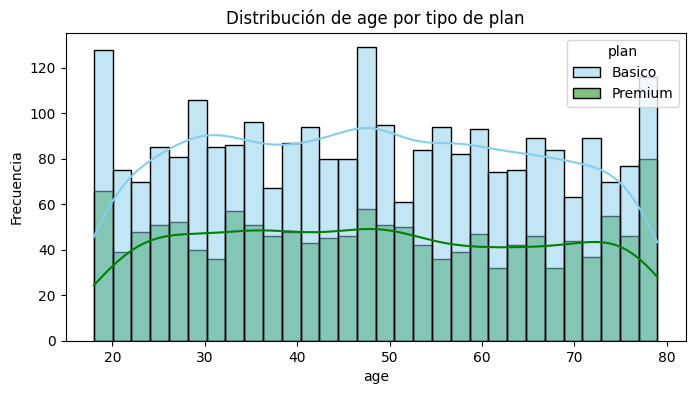

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista de variables
variables = ['age' ]

for var in variables:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=user_profile,
        x=var,
        hue='plan',
        bins=30,
        kde=True,
        palette=['skyblue', 'green']
    )
    plt.title(f'Distribución de {var} por tipo de plan')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

💡Insights: 
- Distribución ...

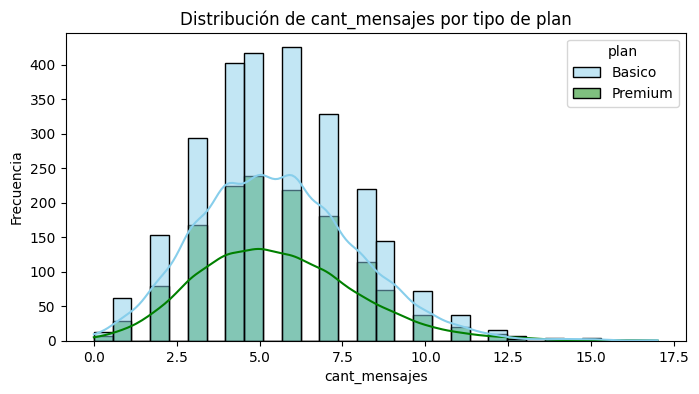

In [51]:
# Histograma para visualizar la cant_mensajes
# Lista de variables
variables = ['cant_mensajes' ]

for var in variables:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=user_profile,
        x=var,
        hue='plan',
        bins=30,
        kde=True,
        palette=['skyblue', 'green']
    )
    plt.title(f'Distribución de {var} por tipo de plan')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

💡Insights: 
- .... Usuarios del plan Premium muestran mayor volumen de mensajes.
Distribución sesgada a la derecha (muchos usuarios con pocos mensajes y pocos con muchos).

- Premium concentra usuarios más activos en mensajería.

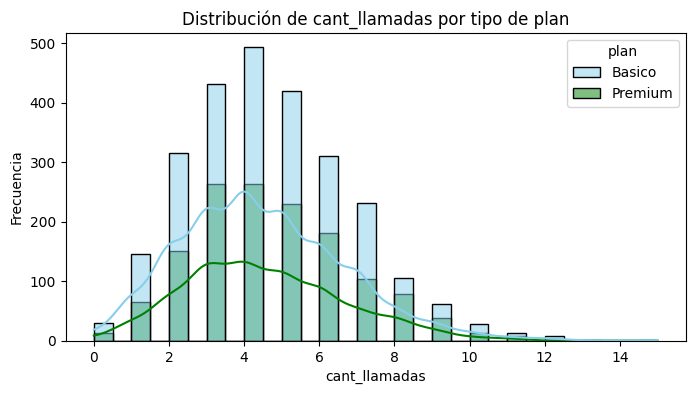

In [52]:
# Histograma para visualizar la cant_llamadas
# Lista de variables
variables = ['cant_llamadas', ]

for var in variables:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=user_profile,
        x=var,
        hue='plan',
        bins=30,
        kde=True,
        palette=['skyblue', 'green']
    )
    plt.title(f'Distribución de {var} por tipo de plan')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

💡Insights: 
- Distribución ... El plan Premium presenta mayor frecuencia de llamadas en comparación con Básico.
Distribución sesgada a la derecha.

- Usuarios Premium tienen mayor uso del servicio de llamadas

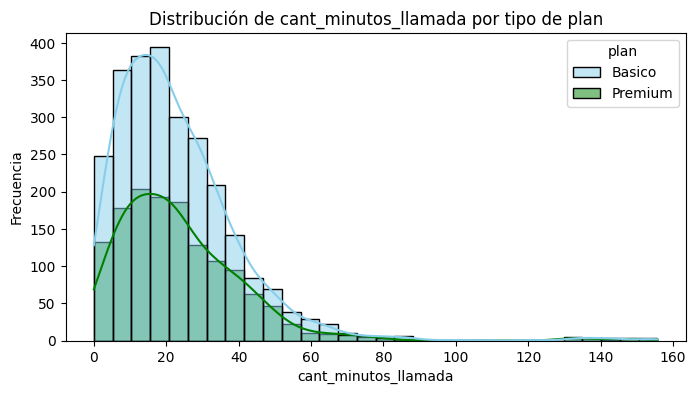

In [53]:
# Histograma para visualizar la cant_minutos_llamada
variables = [ 'cant_minutos_llamada' ]

for var in variables:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=user_profile,
        x=var,
        hue='plan',
        bins=30,
        kde=True,
        palette=['skyblue', 'green']
    )
    plt.title(f'Distribución de {var} por tipo de plan')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

💡Insights: 
- ... Se observa que el plan Premium tiene valores más altos de consumo.
Distribución fuertemente sesgada a la derecha (heavy users).

- Un grupo pequeño de usuarios concentra gran parte del consumo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

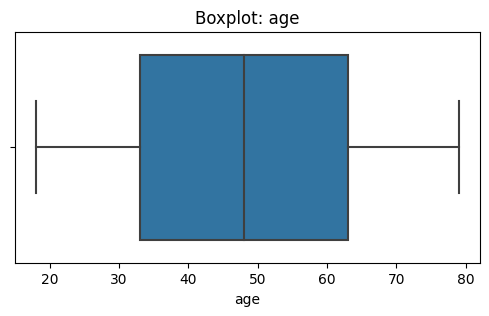

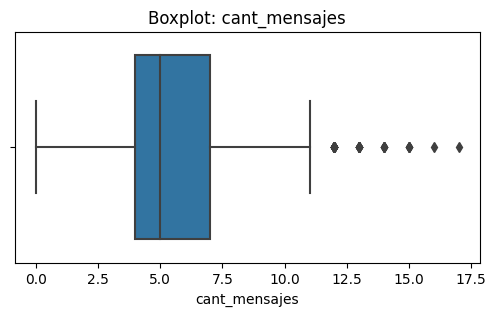

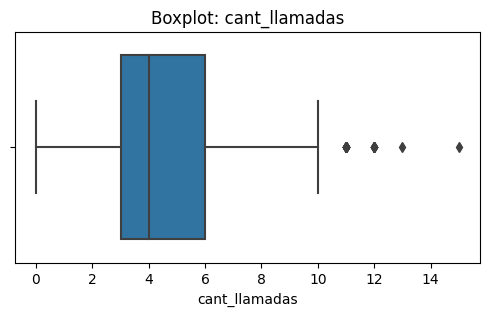

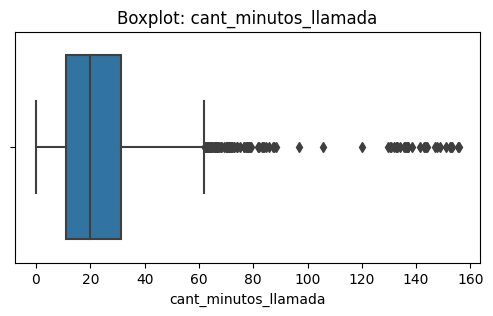

In [55]:
# Visualizando usando BoxPlot 
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 

age → pocos outliers (posibles valores extremos, revisar si son errores)
cant_mensajes → sí, outliers altos (usuarios intensivos)
cant_llamadas → sí, outliers altos
cant_minutos_llamada → outliers muy marcados (heavy users)

 En general, los outliers aparecen principalmente en el lado superior.

In [56]:
# Calcular límites con el método IQR
#columnas_limites = [...]

for col in cols:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + 1.5 * IQR

    print(f"\n=== {col} ===")
    print(f"Upper limit: {upper_limit}")
    
    outliers = user_profile[user_profile[col] > upper_limit]
    print(f"Cantidad de outliers: {len(outliers)}")


=== age ===
Upper limit: 108.0
Cantidad de outliers: 0

=== cant_mensajes ===
Upper limit: 11.5
Cantidad de outliers: 46

=== cant_llamadas ===
Upper limit: 10.5
Cantidad de outliers: 30

=== cant_minutos_llamada ===
Upper limit: 61.8575
Cantidad de outliers: 109


In [60]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
#user_profile[columnas_limites].describe()
user_profile[col].describe()
#user_profile[cols].describe()

count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

Los outliers se concentran en el extremo superior y corresponden a usuarios con alto nivel de consumo, por lo que no se consideran errores de datos.

Acción recomendada:
→ Mantener los outliers y analizarlos como segmento (heavy users)

Justificación 
 Representan comportamiento real relevante para el negocio.

 Si elimino los outliers, corro el riesgo de eliminar comportamientos reales de usuarios intensivos, lo que sesga el análisis y genera una visión incompleta del negocio

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [61]:
# Crear columna grupo_uso
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [62]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [67]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)


In [68]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [69]:
pd.qcut(user_profile['age'], q=3)

0       (17.999, 38.0]
1         (38.0, 58.0]
2         (38.0, 58.0]
3         (58.0, 79.0]
4         (58.0, 79.0]
             ...      
3995      (58.0, 79.0]
3996    (17.999, 38.0]
3997      (38.0, 58.0]
3998      (38.0, 58.0]
3999    (17.999, 38.0]
Name: age, Length: 4000, dtype: category
Categories (3, interval[float64]): [(17.999, 38.0] < (38.0, 58.0] < (58.0, 79.0]]

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

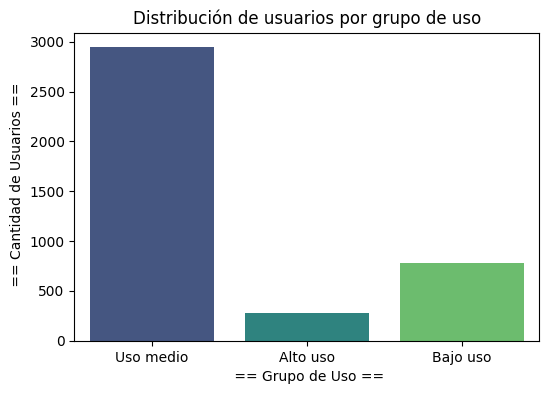

In [72]:
# Visualización de los segmentos por uso

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel(' == Grupo de Uso ==')
plt.ylabel(' == Cantidad de Usuarios ==')

plt.show()

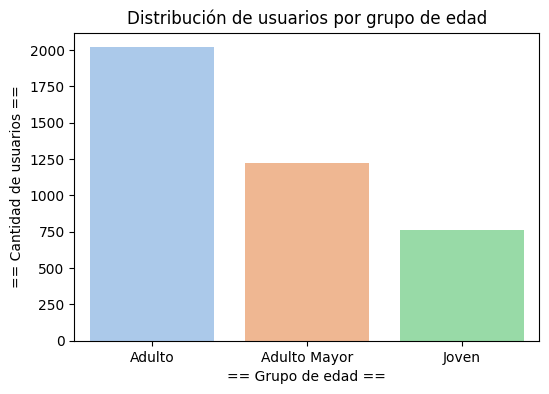

In [74]:
# Visualización de los segmentos por edad

plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_edad', palette='pastel')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('== Grupo de edad ==')
plt.ylabel('== Cantidad de usuarios ==')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron sentinels en age (-999) que representaban un porcentaje bajo, los cuales fueron imputados con la mediana para evitar sesgo.
- En city, valores como "?" fueron convertidos a nulos, ya que no representaban categorías válidas.
- Se detectaron fechas fuera de rango (ej. 2026) en reg_date, inconsistentes con el periodo de análisis (hasta 2024), las cuales fueron marcadas como nulas.
- En usage, se observaron valores nulos en duration y length, los cuales dependen del tipo de evento (call vs text), por lo que se interpretaron como datos no      aplicables (MAR).
- Se detectaron pocos valores nulos en date, los cuales fueron eliminados por su baja proporción y falta de contexto temporal.

-* En general, los problemas eran controlados y corregibles, sin comprometer la calidad global del dataset.

🔍 **Segmentos por Edad**
-Jóvenes (<30): representan una parte importante de la base y muestran comportamiento variado.
-Adultos (30–59): constituyen el segmento más estable y numeroso.
-Adultos mayores (≥60): menor proporción, pero potencialmente con patrones de uso diferenciados.

-* No se observa una segmentación extremadamente desbalanceada, pero la edad por sí sola no explica completamente el comportamiento de uso.


📊 **Segmentos por Nivel de Uso**
- Bajo uso: usuarios con poca actividad; posible riesgo de churn o baja adopción.
Uso medio: segmento más estable, representa el comportamiento típico.
- Alto uso (heavy users): pequeño grupo con consumo elevado de llamadas y minutos.

-* Se observa una distribución sesgada a la derecha, donde pocos usuarios concentran gran parte del consumo.

▲ Segmentos más valiosos
Los usuarios de alto uso son los más valiosos, ya que:
-Generan mayor consumo del servicio
-Representan mayor ingreso potencial
-Pueden requerir planes diferenciados

-* Este segmento es clave para estrategias de upselling y retención premium.

➡️ Esto sugiere que ...
El comportamiento de los usuarios no es homogéneo
Existe una clara separación entre usuarios de bajo y alto consumo
Los planes actuales podrían no estar alineados con estos patrones reales

💡 **Recomendaciones**
-🔹 1. Rediseño de planes
Crear planes diferenciados:
Básico → para bajo uso
Estándar → uso medio
Premium → heavy users
🔹 2. Estrategia de upselling
Identificar usuarios cercanos a límites de uso
ofrecer upgrades personalizados
🔹 3. Gestión de usuarios inactivos
campañas de activación
incentivos para aumentar uso
🔹 4. Segmentación avanzada
combinar:
edad
uso
plan

👉 para personalización real

🔹 5. Monitoreo de outliers
no eliminarlos
analizarlos como segmento estratégico

💡 INSIGHT FINAL

👉 El negocio no está en el promedio, está en los extremos: los heavy users.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`